# Welcome to my Sentinels Valorant Data Analysis Project

I'll be taking a look data on the Sentinels Valorant Team across 2 different regional events, looking at statistics from custom datasets to look at what the team has struggled with, improved on, and seeing if changes they made were worth it  
For some context, the team came into 2026 losing most of their roster and introducing a couple of rookies, as well as 2 crucial role swaps that seemed to have defined their Kickoff. After they were knocked out of the tournament, they fired their coach Kaplan and made 2 roster moves sending away Kyu and N4rrate switching in-game leaders back to their original johnqt. The 2 replacements for Kyu and N4rrate were JonahP and tier-2 upcoming star Jerrwin.

In the beginning of 2026 at Americas Kickoff, the players and roles were as follows:  
- Duelist: N4RRATE
- Initiator: Kyu (igl)
- Sentinel: cortezia
- Controller / Secondary Duelist: reduxx
- Flex: johnqt

Then at the beginning of Stage 1, after switching out 2 players and more roles, it became:  
- Duelist: Jerrwin
- Initiator: JonahP
- Sentinel: cortezia
- Controller / Secondary Duelist: reduxx
- Flex: johnqt (igl)

### First, we'll take a look at our datasets below

Dataset 1: reg_players_kickoff.csv  
This dataset contains overall individual stats across all the players who participated in VCT Americas Kickoff: 2026  
This data was collected via a WebScrape from the website url "https://www.vlr.gg/event/stats/2682/vct-2026-americas-kickoff"

Dataset 2: reg_players_s1.csv  
This dataset contains overall individual statistics across all the players who participated in VCT Americas Stage 1: 2026  
This data was also collected via a WebScrape from the website url "https://www.vlr.gg/event/stats/2860/vct-2026-americas-stage-1"

Dataset 3: indi_by_series.csv  
This dataset contains individual statistics across different series for each of the Sentinels players across both Kickoff and Stage 1  
This data was collected via manual inputs from each series Sentinels participated in (9 series)

Dataset 4: reg_teams_kickoff.csv  
This dataset contains overall regional team statistics pertaining to round results / winrates  
This data was collected via manual inputs from "https://www.thespike.gg/valorant-stats/teams#event=3944"

Dataset 5: reg_teams_s1.csv  
This dataset is identical to Dataset 4, however is from "https://www.thespike.gg/valorant-stats/teams#event=4044"

Dataset 6: vod_review.csv  
This dataset contains round-by-round data collection by each individual on the Sentinels team, tracking every round, every map, and every series from Kickoff and Stage 1

Before we work with the datasets, we have to clean them, but before we clean them, we have to make some imports before we can have functional code!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests # For scraping
from bs4 import BeautifulSoup # For scraping
from pathlib import Path

Dataset 1 + 2 Scraping

In [2]:
def scrape_vlr(url):
    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    response = requests.get(url, headers=headers)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    table = soup.find("table", class_="wf-table mod-stats mod-scroll")

    if table is None:
        raise ValueError("Could not find stats table.")

    rows = []

    for tr in table.find("tbody").find_all("tr"):
        tds = tr.find_all("td")

        if len(tds) < 14:
            continue

        row = {
            "player": tds[0].get_text(strip=True),
            "rating": tds[3].get_text(strip=True),
            "acs": tds[4].get_text(strip=True),
            "kd": tds[5].get_text(strip=True),
            "kast": tds[6].get_text(strip=True),
            "adr": tds[7].get_text(strip=True),
            "kpr": tds[8].get_text(strip=True),
            "apr": tds[9].get_text(strip=True),
            "fkpr": tds[10].get_text(strip=True),
            "fdpr": tds[11].get_text(strip=True),
            "hs_percent": tds[12].get_text(strip=True),
            "cl_percent": tds[13].get_text(strip=True),
        }

        rows.append(row)

    df = pd.DataFrame(rows)

    return df

reg_players_kickoff_df = scrape_vlr("https://www.vlr.gg/event/stats/2682/vct-2026-americas-kickoff")
reg_players_s1_df = scrape_vlr("https://www.vlr.gg/event/stats/2860/vct-2026-americas-stage-1")

reg_players_kickoff_df.to_csv(Path("clean_data") / "reg_players_kickoff.csv", index=False)
reg_players_s1_df.to_csv(Path("clean_data") / "reg_players_s1.csv", index=False)

Dataset 3 Cleaning

In [3]:
def sen_series_clean(input_path):
    df = pd.read_csv(input_path)
    
    df['cl_percent'] = df['cl_percent'].fillna(0)

    for col in ["kast", "hs_percent", "cl_percent"]:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace("%", "", regex=False)
                .astype(float) / 100
            )

    numeric_cols = [
        "series_result", "rds_played", "rating", "acs", "kd", "kast", "adr", "kpr", "apr", "fkpr", "fdpr", "hs_percent", "cl_percent"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

indi_by_series_df = sen_series_clean("raw_data/indi_by_series.csv")

indi_by_series_df.to_csv(Path("clean_data") / "indi_by_series.csv", index=False)

Dataset 4 + 5 Cleaning

In [4]:
def teams_clean(input_path):
    df = pd.read_csv(input_path)

    numeric_cols = [
        "wr", "t_wr", "ct_wr", "p_wr"
    ]

    for col in numeric_cols:
        if col in df.columns:
            frac = df[col].str.split("/", expand=True).astype(float)
            df[col] = frac[0] / frac[1] * 100

    return df

reg_teams_kickoff_df = teams_clean("raw_data/reg_teams_kickoff.csv")
reg_teams_s1_df = teams_clean("raw_data/reg_teams_s1.csv")

reg_teams_kickoff_df.to_csv(Path("clean_data") / "reg_teams_kickoff.csv", index=False)
reg_teams_s1_df.to_csv(Path("clean_data") / "reg_teams_s1.csv", index=False)

Dataset 6 Cleaning

In [5]:
def vod_clean(input_path):
    df = pd.read_csv(input_path)

    numeric_cols = [
        "round", "spike_planted", "plant_time", "fk_time", "round_win", "johnqt_k_pre", "reduxx_k_pre", "cortezia_k_pre", "n4rrate_k_pre", "kyu_k_pre",
        "jonahp_k_pre", "victor_k_pre", "jerrwin_k_pre", "johnqt_k_post", "reduxx_k_post", "cortezia_k_post", "n4rrate_k_post", "kyu_k_post", "jonahp_k_post", 
        "victor_k_post", "jerrwin_k_post"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

vod_review_df = vod_clean("raw_data/vod_review.csv")

vod_review_df.to_csv(Path("clean_data") / "vod_review.csv", index=False)

With these datasets, I want to compare some overall statistics to some more nitpick statistics within the rounds in order to compare overall team performance, and individual player performance  
The player roles between Kickoff and Stage 1 are as follows:  
- Main Duelist: N4RRATE --> Jerrwin  
- Initiator: Kyu --> JonahP  
- Sentinel: cortezia  
- Smokes: Reduxx  
- Flex: johnqt  
- IGL: Kyu --> johnqt

Let's first look at overall team performances between Kickoff and Stage 1

In [6]:
print("Kickoff Team Stats")
print(reg_teams_kickoff_df)
print("\nStage 1 Team Stats")
print(reg_teams_s1_df)

Kickoff Team Stats
   team_name         wr       t_wr      ct_wr       p_wr
0        fur  64.285714  57.812500  51.879699  69.230769
1         g2  58.823529  57.575758  54.471545  50.000000
2        nrg  50.000000  55.487805  53.548387  62.500000
3       100t  45.833333  55.924171  49.344978  35.000000
4         c9  42.857143  50.967742  50.256410  40.625000
5       mibr  38.095238  53.631285  41.621622  33.333333
6       envy  33.333333  43.870968  54.362416  53.846154
7        lev  33.333333  43.965517  48.695652  72.727273
8         eg  33.333333  46.280992  55.555556  59.090909
9        kru  22.222222  39.361702  42.857143  18.750000
10       sen  16.666667  46.000000  47.777778  62.500000
11      loud  11.111111  36.470588  40.983607  57.142857

Stage 1 Team Stats
   team_name         wr       t_wr      ct_wr       p_wr
0         g2  52.941176  54.385965  53.560372  51.785714
1        lev  51.724138  57.090909  52.611940  48.076923
2        nrg  48.275862  52.892562  54.251012  56

We can see that from Kickoff to Stage 1:  
- Overall Map Winrate: 16.66% --> 40% &uarr;
- T-Side Winrate: 46% --> 44.93% &darr;
- CT-Side Winrate: 47.78% --> 52.21% &uarr;
- Pistol Round Winrate: 62.5% --> 54.17% &darr;

They've improved in some areas but also regressed in others, now let's see how they performed relative to the rest of the region

In [7]:
def rank_team_stats(df):
    ranked = df.copy()

    stat_cols = ["wr", "t_wr", "ct_wr", "p_wr"]

    for col in stat_cols:
        ranked[f"{col}_rank"] = (
            ranked[col]
            .rank(ascending=False, method="min")
            .astype(int)
        )

    return ranked

kickoff_ranked = rank_team_stats(reg_teams_kickoff_df)
s1_ranked = rank_team_stats(reg_teams_s1_df)

print("SEN Kickoff Rankings")
print(kickoff_ranked[['team_name', 'wr_rank', 't_wr_rank', 'ct_wr_rank', 'p_wr_rank']])
print("SEN Stage 1 Rankings")
print(s1_ranked[['team_name', 'wr_rank', 't_wr_rank', 'ct_wr_rank', 'p_wr_rank']])

SEN Kickoff Rankings
   team_name  wr_rank  t_wr_rank  ct_wr_rank  p_wr_rank
0        fur        1          1           5          2
1         g2        2          2           2          8
2        nrg        3          4           4          3
3       100t        4          3           7         10
4         c9        5          6           6          9
5       mibr        6          5          11         11
6       envy        7         10           3          7
7        lev        7          9           8          1
8         eg        7          7           1          5
9        kru       10         11          10         12
10       sen       11          8           9          3
11      loud       12         12          12          6
SEN Stage 1 Rankings
   team_name  wr_rank  t_wr_rank  ct_wr_rank  p_wr_rank
0         g2        1          3           2          6
1        lev        2          1           3          8
2        nrg        3          4           1          4
3     

In these different categories:
- Overall Map Winrate: 11 --> 6 &uarr;
- T-Side Winrate: 8 --> 10 &darr;
- CT-Side Winrate: 9 --> 4 &uarr;
- Pistol Round Winrate: 3 --> 5 &darr;

Based on the winrates themselves, and the rankings, from Kickoff, SEN improved on their CT-side significantly while slightly drawing back on their T-Side and Pistol Round winrates.

Let's take a look now at the players

In [8]:
print("Individual Stats - Kickoff")
print(reg_players_kickoff_df[reg_players_kickoff_df["player"].str.contains("SEN", case=False, na=False)])
print("\nIndividual Stats - Stage 1")
print(reg_players_s1_df[reg_players_s1_df["player"].str.contains("SEN", case=False, na=False)])

Individual Stats - Kickoff
         player rating    acs    kd kast    adr   kpr   apr  fkpr  fdpr  \
0     johnqtSEN   1.28  216.3  1.39  79%  141.9  0.79  0.30  0.04  0.03   
36    ReduxxSEN   0.95  189.0  0.96  67%  127.4  0.68  0.22  0.18  0.17   
44       KyuSEN   0.90  176.8  0.86  68%  114.0  0.60  0.28  0.05  0.09   
51  corteziaSEN   0.85  175.6  0.85  67%  126.2  0.59  0.20  0.07  0.08   
58   N4RRATESEN   0.80  187.1  0.79  69%  124.3  0.62  0.23  0.14  0.14   

   hs_percent cl_percent  
0         31%        23%  
36        33%             
44        21%        12%  
51        31%        11%  
58        22%             

Individual Stats - Stage 1
         player rating    acs    kd kast    adr   kpr   apr  fkpr  fdpr  \
3   corteziaSEN   1.15  209.3  1.21  72%  139.0  0.76  0.20  0.12  0.09   
19    ReduxxSEN   1.06  218.3  1.06  71%  139.6  0.78  0.24  0.09  0.07   
39    johnqtSEN   0.95  167.3  0.91  66%  110.1  0.58  0.30  0.02  0.06   
51    JonahPSEN   0.88  178.5  0

From Kickoff to Stage 1 on direct player comparisons, focusing on Player Rating:
- johnqt: 1.28 --> 0.95
- Reduxx: 0.95 --> 1.06
- cortezia: 0.85 --> 1.15
- Kyu to JonahP: 0.9 --> 0.88
- N4RRATE to Jerrwin: 0.8 --> 0.82

From Player Rating alone, johnqt held back while Reduxx and cortezia stepped up largely, and Kyu and N4RRATE's replacements JonahP and Jerrwin had performed almost identically, so are these players one-to-one replacements, or are there other statistics that contributed to their greater/lesser impact? Maybe we can take a look at the rankings amongst other individual players.

In [9]:
def rank_indi_stats(df):
    ranked = df.copy()

    stat_cols = ["rating", "acs", "kd", "kast", "adr", "kpr", "apr", "fkpr", "fdpr", "hs_percent", "cl_percent"]

    for col in stat_cols:
        ranked[f"{col}_rank"] = (
            ranked[col]
            .rank(ascending=False, method="min")
            .astype(int)
        )

    return ranked

kickoff_ranked = rank_indi_stats(reg_players_kickoff_df)
s1_ranked = rank_indi_stats(reg_players_s1_df)

print("SEN Kickoff Rankings")
print(
    kickoff_ranked[
        kickoff_ranked["player"].str.contains("SEN", case=False, na=False)
    ][[
        "player",
        "rating_rank",
        "acs_rank",
        "kd_rank",
        "kast_rank",
        "adr_rank",
        "kpr_rank",
        "apr_rank",
        "fkpr_rank",
        "fdpr_rank",
        "hs_percent_rank",
        "cl_percent_rank"
    ]]
)

print("\nSEN Stage 1 Rankings")
print(
    s1_ranked[
        s1_ranked["player"].str.contains("SEN", case=False, na=False)
    ][[
        "player",
        "rating_rank",
        "acs_rank",
        "kd_rank",
        "kast_rank",
        "adr_rank",
        "kpr_rank",
        "apr_rank",
        "fkpr_rank",
        "fdpr_rank",
        "hs_percent_rank",
        "cl_percent_rank"
    ]]
)

SEN Kickoff Rankings
         player  rating_rank  acs_rank  kd_rank  kast_rank  adr_rank  \
0     johnqtSEN            1        10        1          1         9   
36    ReduxxSEN           35        34       33         53        30   
44       KyuSEN           44        45       46         49        51   
51  corteziaSEN           52        46       47         53        33   
58   N4RRATESEN           59        39       56         42        35   

    kpr_rank  apr_rank  fkpr_rank  fdpr_rank  hs_percent_rank  cl_percent_rank  
0          8        18         59         61               10               21  
36        28        41          7          6                6               59  
44        49        23         48         31               54               45  
51        51        50         37         38               10               52  
58        45        37         11         12               52               59  

SEN Stage 1 Rankings
         player  rating_rank  acs_rank

The most notable thing here is that Jerrwin was at a noticeably higher rank in First Kill Per Round and First Death Per Round rankings in comparison to N4RRATE who was the previous main duelist of the team  
Jerrwin was ranked 4 and 5 whereas N4RRATE was 11 and 12. This indicates Jerrwin was better in space creation and taking more first duels for the team  
By the rankings, johnqt had seemed to step back a lot, but that's also due to the change in his role, going back to IGL'ing for the team, and IGL's typically don't frag hard or top the scoreboards.

Now we're going to take a look at more round-specific statistics, and to do that we're going to focus on the vod_review dataset  
In team round winrates, we see that there were a lot of changes between Kickoff and Stage 1:  
- The T-Side stayed mostly consistent only dropping 1%
- The CT-Side increased by ~4.5%
- And the Pistol round winrates decreased by more than 8%  

Let's take a look at why that is, from player impact, and the way I'll be measuring that is determining a player's kills in a round to the round winrate. It's hard to look at all of them right together so let's look at them individually by Pistol, T-Side, and CT-Side. For each category, we'll look at a player's impact on the round winning or losing the initial duel (or taking or giving a first kill), and a player even getting a kill in the round in general. For Pistol rounds we won't look at first kills and first deaths because the sample size is very small.  

However first let's look at rounds overall first!

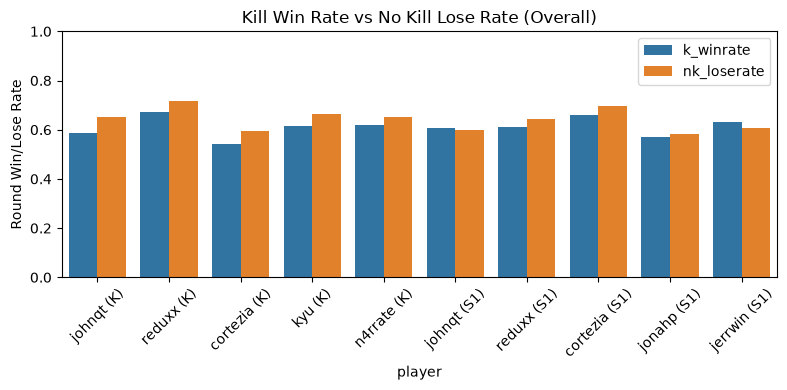

In [10]:
overall_k = vod_review_df[vod_review_df['event'] == 'amer_kickoff_2026']
overall_s1 = vod_review_df[vod_review_df['event'] == 'amer_stage_1_2026']

players_k = [
    ('johnqt_k_pre', 'johnqt_k_post'),
    ('reduxx_k_pre', 'reduxx_k_post'),
    ('cortezia_k_pre', 'cortezia_k_post'),
    ('kyu_k_pre', 'kyu_k_post'),
    ('n4rrate_k_pre', 'n4rrate_k_post')
]

players_s1 = [
    ('johnqt_k_pre', 'johnqt_k_post'),
    ('reduxx_k_pre', 'reduxx_k_post'),
    ('cortezia_k_pre', 'cortezia_k_post'),
    ('jonahp_k_pre', 'jonahp_k_post'),
    ('jerrwin_k_pre', 'jerrwin_k_post')
]

rows = []

for pre_col, post_col in players_k:
    kill_mask = overall_k[[pre_col, post_col]].ge(1).any(axis=1)
    no_kill_mask = overall_k[[pre_col, post_col]].fillna(0).lt(1).all(axis=1)

    rows.append({
        'player': pre_col.replace('_k_pre', '') + ' (K)',
        'k_winrate': overall_k.loc[kill_mask, 'round_win'].mean(),
        'nk_loserate': 1 - overall_k.loc[no_kill_mask, 'round_win'].mean()
    })

for pre_col, post_col in players_s1:
    kill_mask = overall_s1[[pre_col, post_col]].ge(1).any(axis=1) # masks out rounds where x player had at least one kill pre-/post-plant
    no_kill_mask = overall_s1[[pre_col, post_col]].fillna(0).lt(1).all(axis=1) # masks out rounds where x player had no kills in both pre-/post-plant

    rows.append({
        'player': pre_col.replace('_k_pre', '') + ' (S1)',
        'k_winrate': overall_s1.loc[kill_mask, 'round_win'].mean(),
        'nk_loserate': 1 - overall_s1.loc[no_kill_mask, 'round_win'].mean()
    })

plot_df = pd.DataFrame(rows)

plot_df_long = plot_df.melt(
    id_vars='player',
    value_vars=['k_winrate', 'nk_loserate'],
    var_name='side',
    value_name='rate'
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df_long,
    x='player',
    y='rate',
    hue='side'
)

plt.ylabel('Round Win/Lose Rate')
plt.title('Kill Win Rate vs No Kill Lose Rate (Overall)')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(title='')
plt.tight_layout()
plt.show()

There are a couple outliers on both ends of the spectrum. First, in kill contribution to winrate, some standout highs are Reduxx during Kickoff, and cortezia during Stage 1, having the most positive impact on the round when getting a kill. Some standout lows for the team are cortezia during Kickoff, and jonahp during Stage 1, contributing lower impact to the team's winrate when getting a kill in the round.

Now in not getting a kill to the team's lose rate, we see the same standout highs and lows.

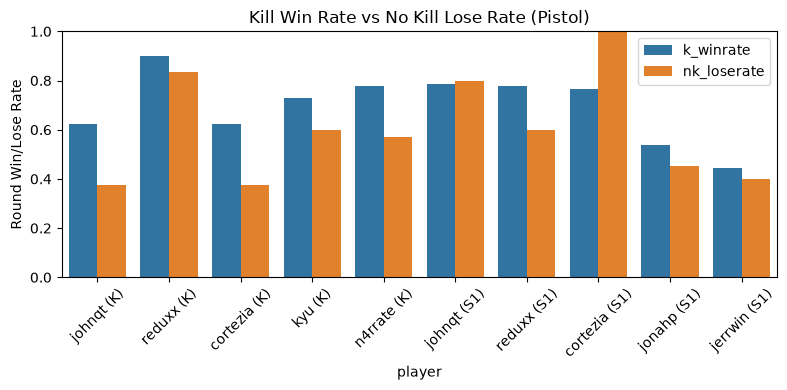

In [11]:
pistols = vod_review_df[(vod_review_df['round'] == 1) | (vod_review_df['round'] == 13)]
pistols_k = pistols[pistols['event'] == 'amer_kickoff_2026']
pistols_s1 = pistols[pistols['event'] == 'amer_stage_1_2026']

players_k = [
    ('johnqt_k_pre', 'johnqt_k_post'),
    ('reduxx_k_pre', 'reduxx_k_post'),
    ('cortezia_k_pre', 'cortezia_k_post'),
    ('kyu_k_pre', 'kyu_k_post'),
    ('n4rrate_k_pre', 'n4rrate_k_post')
]

players_s1 = [
    ('johnqt_k_pre', 'johnqt_k_post'),
    ('reduxx_k_pre', 'reduxx_k_post'),
    ('cortezia_k_pre', 'cortezia_k_post'),
    ('jonahp_k_pre', 'jonahp_k_post'),
    ('jerrwin_k_pre', 'jerrwin_k_post')
]

rows = []

for pre_col, post_col in players_k:
    kill_mask = pistols_k[[pre_col, post_col]].ge(1).any(axis=1)
    no_kill_mask = pistols_k[[pre_col, post_col]].fillna(0).lt(1).all(axis=1)

    rows.append({
        'player': pre_col.replace('_k_pre', '') + ' (K)',
        'k_winrate': pistols_k.loc[kill_mask, 'round_win'].mean(),
        'nk_loserate': 1 - pistols_k.loc[no_kill_mask, 'round_win'].mean()
    })

for pre_col, post_col in players_s1:
    kill_mask = pistols_s1[[pre_col, post_col]].ge(1).any(axis=1) # masks out rounds where x player had at least one kill pre-/post-plant
    no_kill_mask = pistols_s1[[pre_col, post_col]].fillna(0).lt(1).all(axis=1) # masks out rounds where x player had no kills in both pre-/post-plant

    rows.append({
        'player': pre_col.replace('_k_pre', '') + ' (S1)',
        'k_winrate': pistols_s1.loc[kill_mask, 'round_win'].mean(),
        'nk_loserate': 1 - pistols_s1.loc[no_kill_mask, 'round_win'].mean()
    })

plot_df = pd.DataFrame(rows)

plot_df_long = plot_df.melt(
    id_vars='player',
    value_vars=['k_winrate', 'nk_loserate'],
    var_name='side',
    value_name='rate'
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df_long,
    x='player',
    y='rate',
    hue='side'
)

plt.ylabel('Round Win/Lose Rate')
plt.title('Kill Win Rate vs No Kill Lose Rate (Pistol)')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(title='')
plt.tight_layout()
plt.show()

From this, we can see that in Kickoff, the more impactful players in the Pistol rounds were Reduxx, Kyu, and N4RRATE, contributing to higher winrates in the rounds when they got a kill. But Reduxx is the only standout where his lack of a kill impacted the round more than everyone else.

In Stage 1, the more impactful players in the Pistol rounds were johnqt, reduxx, and cortezia, contributing to higher winrates in the rounds when they got a kill. johnqt and cortezia stand out more in the rounds where they didn't get a kill, especially cortezia, SEN loses 100% of the rounds when he doesn't get a kill.  

Now let's take a look at each half instead of pistol rounds, on Attacking (T-Side) and Defending (CT-Side) halves

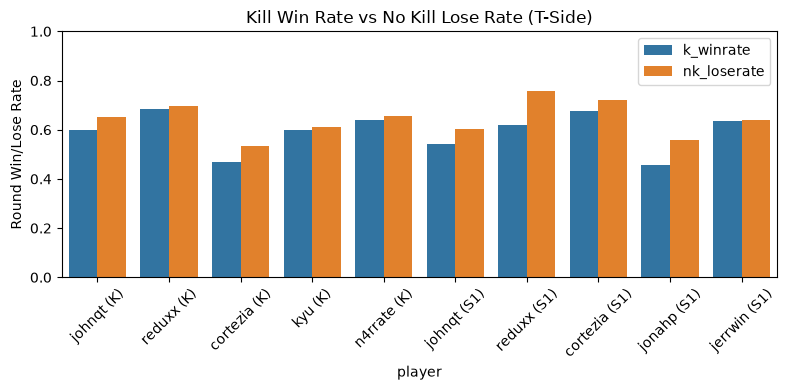

Average T-Side Winrate in Kickoff was 46.81%
Average T-Side Winrate in Stage 1 was 44.93%


In [23]:
t_side = vod_review_df[(vod_review_df['side'] == 't')]
t_side_k = t_side[t_side['event'] == 'amer_kickoff_2026']
t_side_s1 = t_side[t_side['event'] == 'amer_stage_1_2026']

players_k = [
    ('johnqt_k_pre', 'johnqt_k_post'),
    ('reduxx_k_pre', 'reduxx_k_post'),
    ('cortezia_k_pre', 'cortezia_k_post'),
    ('kyu_k_pre', 'kyu_k_post'),
    ('n4rrate_k_pre', 'n4rrate_k_post')
]

players_s1 = [
    ('johnqt_k_pre', 'johnqt_k_post'),
    ('reduxx_k_pre', 'reduxx_k_post'),
    ('cortezia_k_pre', 'cortezia_k_post'),
    ('jonahp_k_pre', 'jonahp_k_post'),
    ('jerrwin_k_pre', 'jerrwin_k_post')
]

rows = []

for pre_col, post_col in players_k:
    kill_mask = t_side_k[[pre_col, post_col]].ge(1).any(axis=1)
    no_kill_mask = t_side_k[[pre_col, post_col]].fillna(0).lt(1).all(axis=1)

    rows.append({
        'player': pre_col.replace('_k_pre', '') + ' (K)',
        'k_winrate': t_side_k.loc[kill_mask, 'round_win'].mean(),
        'nk_loserate': 1 - t_side_k.loc[no_kill_mask, 'round_win'].mean()
    })

for pre_col, post_col in players_s1:
    kill_mask = t_side_s1[[pre_col, post_col]].ge(1).any(axis=1) # masks out rounds where x player had at least one kill pre-/post-plant
    no_kill_mask = t_side_s1[[pre_col, post_col]].fillna(0).lt(1).all(axis=1) # masks out rounds where x player had no kills in both pre-/post-plant

    rows.append({
        'player': pre_col.replace('_k_pre', '') + ' (S1)',
        'k_winrate': t_side_s1.loc[kill_mask, 'round_win'].mean(),
        'nk_loserate': 1 - t_side_s1.loc[no_kill_mask, 'round_win'].mean()
    })

plot_df = pd.DataFrame(rows)

plot_df_long = plot_df.melt(
    id_vars='player',
    value_vars=['k_winrate', 'nk_loserate'],
    var_name='side',
    value_name='rate'
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df_long,
    x='player',
    y='rate',
    hue='side'
)

plt.ylabel('Round Win/Lose Rate')
plt.title('Kill Win Rate vs No Kill Lose Rate (T-Side)')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(title='')
plt.tight_layout()
plt.show()

print("Average T-Side Winrate in Kickoff was " + str((t_side_k['round_win'].mean() * 100).round(2)) + "%")
print("Average T-Side Winrate in Stage 1 was " + str((t_side_s1['round_win'].mean() * 100).round(2)) + "%")

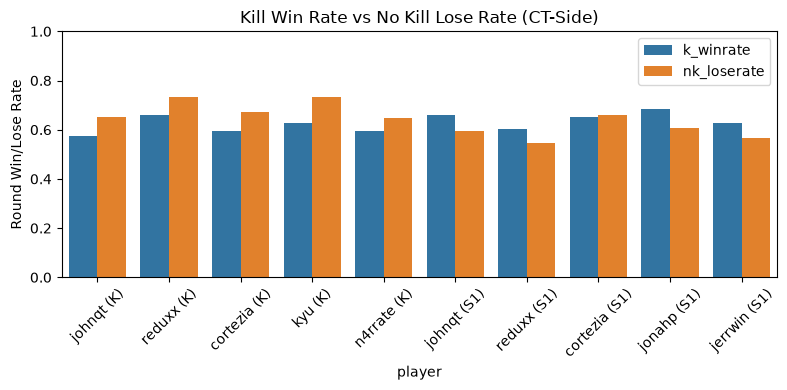

Average CT-Side Winrate in Kickoff was 45.83%
Average CT-Side Winrate in Stage 1 was 52.21%


In [24]:
ct_side = vod_review_df[(vod_review_df['side'] == 'ct')]
ct_side_k = ct_side[ct_side['event'] == 'amer_kickoff_2026']
ct_side_s1 = ct_side[ct_side['event'] == 'amer_stage_1_2026']

players_k = [
    ('johnqt_k_pre', 'johnqt_k_post'),
    ('reduxx_k_pre', 'reduxx_k_post'),
    ('cortezia_k_pre', 'cortezia_k_post'),
    ('kyu_k_pre', 'kyu_k_post'),
    ('n4rrate_k_pre', 'n4rrate_k_post')
]

players_s1 = [
    ('johnqt_k_pre', 'johnqt_k_post'),
    ('reduxx_k_pre', 'reduxx_k_post'),
    ('cortezia_k_pre', 'cortezia_k_post'),
    ('jonahp_k_pre', 'jonahp_k_post'),
    ('jerrwin_k_pre', 'jerrwin_k_post')
]

rows = []

for pre_col, post_col in players_k:
    kill_mask = ct_side_k[[pre_col, post_col]].ge(1).any(axis=1)
    no_kill_mask = ct_side_k[[pre_col, post_col]].fillna(0).lt(1).all(axis=1)

    rows.append({
        'player': pre_col.replace('_k_pre', '') + ' (K)',
        'k_winrate': ct_side_k.loc[kill_mask, 'round_win'].mean(),
        'nk_loserate': 1 - ct_side_k.loc[no_kill_mask, 'round_win'].mean()
    })

for pre_col, post_col in players_s1:
    kill_mask = ct_side_s1[[pre_col, post_col]].ge(1).any(axis=1) # masks out rounds where x player had at least one kill pre-/post-plant
    no_kill_mask = ct_side_s1[[pre_col, post_col]].fillna(0).lt(1).all(axis=1) # masks out rounds where x player had no kills in both pre-/post-plant

    rows.append({
        'player': pre_col.replace('_k_pre', '') + ' (S1)',
        'k_winrate': ct_side_s1.loc[kill_mask, 'round_win'].mean(),
        'nk_loserate': 1 - ct_side_s1.loc[no_kill_mask, 'round_win'].mean()
    })

plot_df = pd.DataFrame(rows)

plot_df_long = plot_df.melt(
    id_vars='player',
    value_vars=['k_winrate', 'nk_loserate'],
    var_name='side',
    value_name='rate'
)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df_long,
    x='player',
    y='rate',
    hue='side'
)

plt.ylabel('Round Win/Lose Rate')
plt.title('Kill Win Rate vs No Kill Lose Rate (CT-Side)')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(title='')
plt.tight_layout()
plt.show()

print("Average CT-Side Winrate in Kickoff was " + str((ct_side_k['round_win'].mean() * 100).round(2)) + "%")
print("Average CT-Side Winrate in Stage 1 was " + str((ct_side_s1['round_win'].mean() * 100).round(2)) + "%")

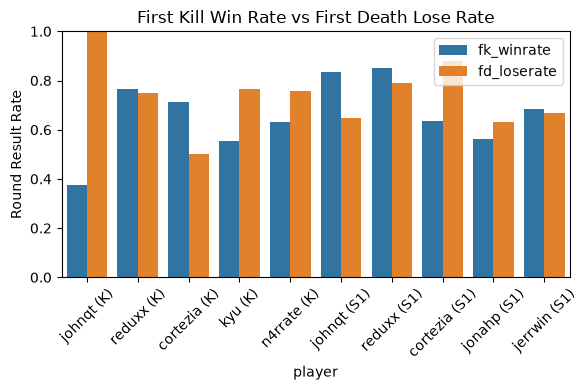

In [13]:
first_kd_k = vod_review_df[vod_review_df['event'] == 'amer_kickoff_2026']
first_kd_s1 = vod_review_df[vod_review_df['event'] == 'amer_stage_1_2026']

players_k = ['johnqt', 'reduxx', 'cortezia', 'kyu', 'n4rrate']
players_s1 = ['johnqt', 'reduxx', 'cortezia', 'jonahp', 'jerrwin']

rows = []

for player in players_k:
    rows.append({
        'player': f'{player} (K)',
        'fk_winrate': first_kd_k.loc[
            first_kd_k['fk_player'] == player,
            'round_win'
        ].mean(),
        'fd_loserate': 1 - first_kd_k.loc[
            first_kd_k['fd_player'] == player,
            'round_win'
        ].mean()
    })

for player in players_s1:
    rows.append({
        'player': f'{player} (S1)',
        'fk_winrate': first_kd_s1.loc[
            first_kd_s1['fk_player'] == player,
            'round_win'
        ].mean(),
        'fd_loserate': 1 - first_kd_s1.loc[
            first_kd_s1['fd_player'] == player,
            'round_win'
        ].mean()
    })

plot_df = pd.DataFrame(rows)

plot_df_long = plot_df.melt(
    id_vars='player',
    value_vars=['fk_winrate', 'fd_loserate'],
    var_name='side',
    value_name='rate'
)

plt.figure(figsize=(6, 4))
sns.barplot(
    data=plot_df_long,
    x='player',
    y='rate',
    hue='side'
)
plt.ylabel('Round Result Rate')
plt.title('First Kill Win Rate vs First Death Lose Rate')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(title='')
plt.tight_layout()
plt.show()

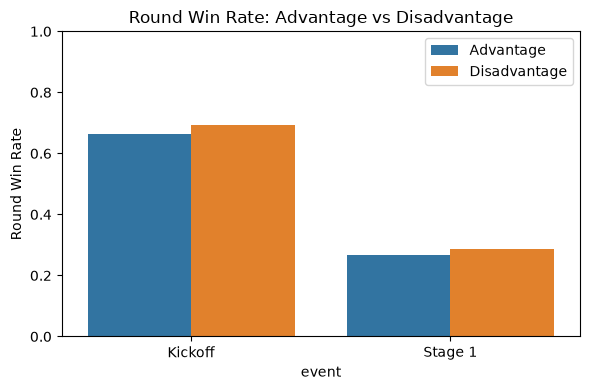

Kickoff Advantage Winrate: 0.6630434782608695
Stage 1 Advantage Winrate: 0.6917293233082706
Kickoff Disadvantage Winrate: 0.26804123711340205
Stage 1 Disadvantage Winrate: 0.28776978417266186


In [20]:
# overall_k from earlier
# overall_s1 also from earlier

adv_k = overall_k.dropna(subset=['fk_player'])
adv_s1 = overall_s1.dropna(subset=['fk_player'])
disadv_k = overall_k.dropna(subset=['fd_player'])
disadv_s1 = overall_s1.dropna(subset=['fd_player'])

adv_k_wr = adv_k['round_win'].mean()
adv_s1_wr = adv_s1['round_win'].mean()
disadv_k_wr = disadv_k['round_win'].mean()
disadv_s1_wr = disadv_s1['round_win'].mean()

plot_df = pd.DataFrame({
    'event': ['Kickoff', 'Kickoff', 'Stage 1', 'Stage 1'],
    'side': ['Advantage', 'Disadvantage', 'Advantage', 'Disadvantage'],
    'win_rate': [adv_k_wr, adv_s1_wr, disadv_k_wr, disadv_s1_wr]
})

plt.figure(figsize=(6, 4))
sns.barplot(data=plot_df, x='event', y='win_rate', hue='side')
plt.ylabel('Round Win Rate')
plt.title('Round Win Rate: Advantage vs Disadvantage')
plt.ylim(0, 1)
plt.legend(title='')
plt.tight_layout()
plt.show()

print("Kickoff Advantage Winrate: " + str(adv_k_wr))
print("Stage 1 Advantage Winrate: " + str(adv_s1_wr))
print("Kickoff Disadvantage Winrate: " + str(disadv_k_wr))
print("Stage 1 Disadvantage Winrate: " + str(disadv_s1_wr))

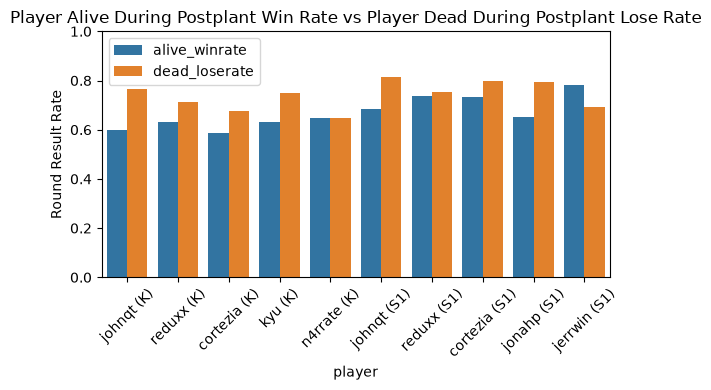

In [ ]:
# overall_k from earlier
# overall_s1 also from earlier

post_plant_k = overall_k[(overall_k['side'] == 't')]
post_plant_s1 = overall_s1[(overall_s1['side'] == 't')]

players_k = ['johnqt', 'reduxx', 'cortezia', 'kyu', 'n4rrate']
players_s1 = ['johnqt', 'reduxx', 'cortezia', 'jonahp', 'jerrwin']

rows = []

for player in players_k:
    col = f'{player}_k_post'

    rows.append({
        'player': f'{player} (K)',
        'alive_winrate': post_plant_k.loc[post_plant_k[col].notna(), 'round_win'].mean(),
        'dead_loserate': 1 - post_plant_k.loc[post_plant_k[col].isna(), 'round_win'].mean()
    })

for player in players_s1:
    col = f'{player}_k_post'

    rows.append({
        'player': f'{player} (S1)',
        'alive_winrate': post_plant_s1.loc[post_plant_s1[col].notna(), 'round_win'].mean(),
        'dead_loserate': 1 - post_plant_s1.loc[post_plant_s1[col].isna(), 'round_win'].mean()
    })

plot_df = pd.DataFrame(rows)

plot_df_long = plot_df.melt(
    id_vars='player',
    value_vars=['alive_winrate', 'dead_loserate'],
    var_name='side',
    value_name='rate'
)

plt.figure(figsize=(6, 4))
sns.barplot(data=plot_df_long, x='player', y='rate', hue='side')
plt.ylabel('Round Result Rate')
plt.title('Player Alive During Postplant Win Rate vs Player Dead During Postplant Lose Rate')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(title='')
plt.tight_layout()
plt.show()

print("Average Postplant Winrate ")

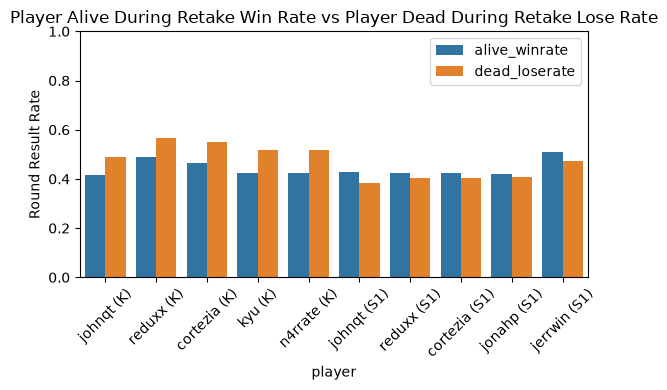

In [22]:
# overall_k from earlier
# overall_s1 also from earlier

post_plant_k = overall_k[(overall_k['side'] == 'ct')]
post_plant_s1 = overall_s1[(overall_s1['side'] == 'ct')]

players_k = ['johnqt', 'reduxx', 'cortezia', 'kyu', 'n4rrate']
players_s1 = ['johnqt', 'reduxx', 'cortezia', 'jonahp', 'jerrwin']

rows = []

for player in players_k:
    col = f'{player}_k_post'

    rows.append({
        'player': f'{player} (K)',
        'alive_winrate': post_plant_k.loc[post_plant_k[col].notna(), 'round_win'].mean(),
        'dead_loserate': 1 - post_plant_k.loc[post_plant_k[col].isna(), 'round_win'].mean()
    })

for player in players_s1:
    col = f'{player}_k_post'

    rows.append({
        'player': f'{player} (S1)',
        'alive_winrate': post_plant_s1.loc[post_plant_s1[col].notna(), 'round_win'].mean(),
        'dead_loserate': 1 - post_plant_s1.loc[post_plant_s1[col].isna(), 'round_win'].mean()
    })

plot_df = pd.DataFrame(rows)

plot_df_long = plot_df.melt(
    id_vars='player',
    value_vars=['alive_winrate', 'dead_loserate'],
    var_name='side',
    value_name='rate'
)

plt.figure(figsize=(6, 4))
sns.barplot(data=plot_df_long, x='player', y='rate', hue='side')
plt.ylabel('Round Result Rate')
plt.title('Player Alive During Retake Win Rate vs Player Dead During Retake Lose Rate')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(title='')
plt.tight_layout()
plt.show()